In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd
from numba import  njit

# Примеры

In [4]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    #Wiener Process by default
    #use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    def Milstein2Solution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1], t_data[i - 1], self.params) - 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params)) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/2 * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) +\
                        1/4 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2 * self.sigmaxt_xx(x_data[i - 1], t_data[i - 1], self.params)) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/4 * self.bxt_xx(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2) * dt**2
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * 1/2 * 1/np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return -params[2] * 1/4 * 1/np.maximum(x,0)**(3/2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def ExactSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        Ito_integral_sum = np.zeros(self.Nx)
        for i in range(1, self.Nt + 1):
            Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data[i]) + theta1/theta2
            #avoiding exp overflow
            Ito_integral_sum = (Ito_integral_sum + theta3 * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]) * np.exp(-theta2 * dt)
            x_data[i] = Determinated_part + Ito_integral_sum
        return t_data, x_data

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1

        return ncx2.rvs(2 * q + 2, 2 * u, size = self.Nx) / (2 * c)

    def ProcessDistribution(self, x, t, x0, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
        u = c * x0 * np.exp(-k * (t - t0))
        #v = c * x
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c) #2c is normalazing constant

    def StationaryDistribution(self, x):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c)

Execise 1. Simulate a Cox-Ingersoll-Ross (CIR) model
$$
dX_t = (\theta_1 - \theta_2 X_t)dt + \theta_3 \sqrt{X_t}dW_t
$$
with $\theta = (6, 2, 1)$, and choose the bandwidth according to Scott’s rule and implement the non-parametric kernel estimation for stationary density of the CIR model.

Plot in a graph the true stationary density against the estimated one for
*   $n=1000$, $\Delta_n=1$,
*   $n=15000$, $\Delta_n=0.01$.



In [ ]:
def StationaryDistributionKernelEstimator(x, x_data, delta = None):
    n = len(x_data)
    m = 1

    hn = 1

    if delta is None:
        hn = np.std(x_data) * n**(-1 / (m + 4))
    else:
        hn = delta

    pi = np.zeros(len(x))

    for j in range(0, len(x)):
        K = 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * (x[j] - x_data)**2 / hn**2)

        pi[j] = 1 / (n * hn) * np.sum(K)

    return pi

In [ ]:
'''Расчёт на 1 траектрии
Для обеспечения стационарности задаём T очень большим. T/Nt = delta t - шаг дискретизации по времени
'''

Nx = 1
Nt = 100000
T = 1000

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

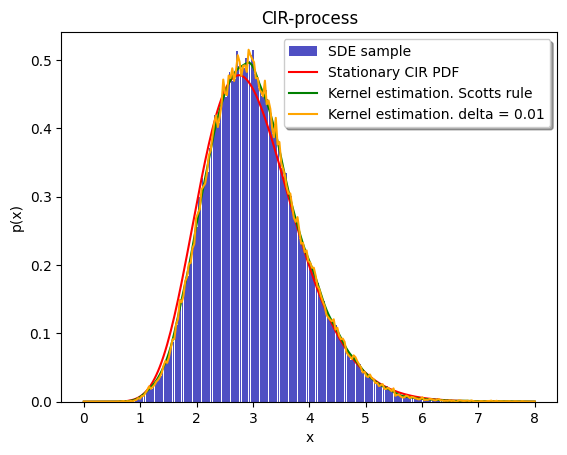

In [ ]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR.flatten(), bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process', loc = 'center')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten()), label = f'Kernel estimation. Scotts rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten(), delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

In [ ]:
'''Расчёт на Nx траектриях
Для обеспечения стационарности задаём число траекторий Nx большим, а так же
в качестве начального состояния задаём стационарное состояние
'''
Nx = 15000
Nt = 300

T = 1

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

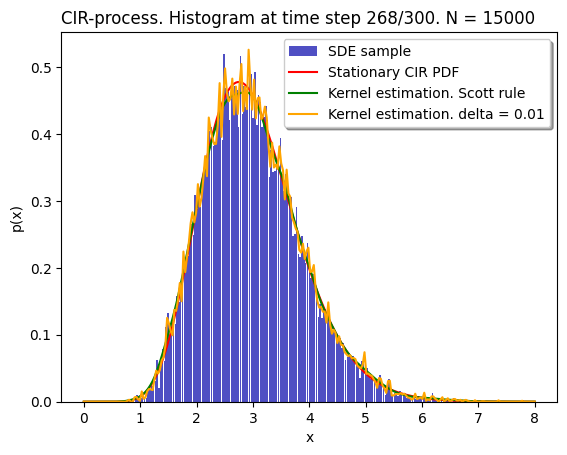

In [ ]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR[i], bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process. Histogram at time step {i}/{Nt}. N = {Nx}', loc = 'left')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i]), label = f'Kernel estimation. Scott rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i], delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

Task. Estimate the quality of the obtained approximations with statistical criteria and provide conclusions.

In [ ]:
# your code

Task. Study the effect of the bandwidth $h_n$ and the mesh $∆_n$ on the kernel estimator and plot a 3D graph.

In [ ]:
# your code

Task 2. Implement a non-parametric drift estimator

$$
\hat{b}_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}
$$

and diffusion estimator
$$
\hat{\sigma}^2_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)^2} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}.$$


for the model from previous item and plot two graphs.
Use the

*  Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}} \exp \left(-\frac{1}{2}u^2\right)$,
*  Uniform kernel $K(u)=1/2$,
*  Epanechnikov (parabolic) kernel $K(u)=\frac{3}{4}(1-u^2)$.


In [ ]:
from typing import Literal

def NormalKernel(z):
    return 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * z**2)

def UniformKernel(z):
    return 1/2 * np.ones_like(z)

def ParabolicKernel(z):
    return 3/4 * (1 - z**2)

def DiffusionKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1])**2)
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

def DriftKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1]))
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

In [ ]:
Nx = 1
Nt = 100000

T = 1000

x_data = np.linspace(0, 6, 200)

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
t_data, x_data_CIR = CIRp.ExactSolution()

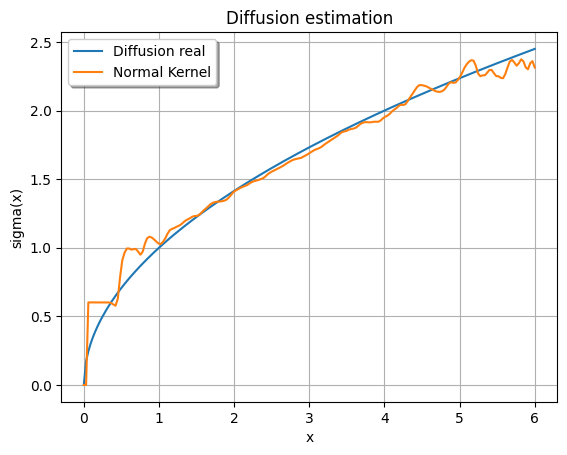

In [ ]:
sigma_data = CIRp.sigmaxt(x_data, 0, CIRp.params)

plt.plot(x_data, sigma_data, label = 'Diffusion real')


diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, np.sqrt(diffke), label = 'Normal Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, np.sqrt(diffke), label = 'Parabolic Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, np.sqrt(diffke), label = 'Uniform Kernel')

plt.title("Diffusion estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(True)
plt.show()

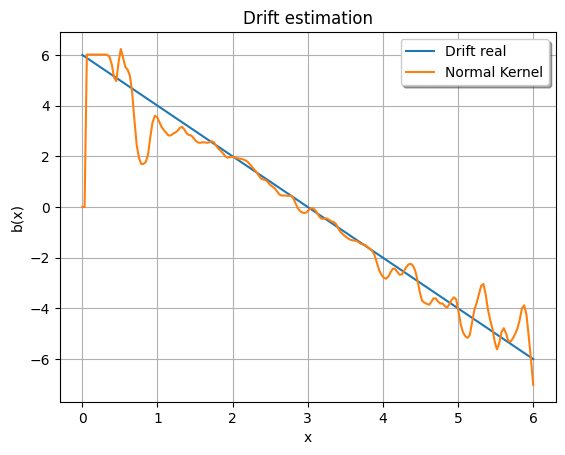

In [ ]:
b_data = CIRp.bxt(x_data, 0, CIRp.params)

plt.plot(x_data, b_data, label = 'Drift real')


driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, driftke, label = 'Normal Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, driftke, label = 'Parabolic Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, driftke, label = 'Uniform Kernel')

plt.title("Drift estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(True)
plt.show()

# Задачи

Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического). Укажите на графике (в легенде или заголовке) какая использована ширина окна (Scott's rule) для ядер.

4. Сделайте выводы.


***

Функции ядер и непараметрической оценки стационарной плотности (по правилу Скотта):

In [6]:
np.random.seed(42)

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def uniform_kernel(u):
    return 0.5 * (np.abs(u) <= 1)

def epanechnikov_kernel(u):
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1)

def StationaryDistributionKernelEstimator(grid_points, sample_values, kernel_name="gaussian", bandwidth=None):
    sample_size = len(sample_values)
    dimension = 1

    if bandwidth is None:
        bandwidth = np.std(sample_values, ddof=1) * sample_size ** (-1 / (dimension + 4))

    density_estimate = np.zeros(len(grid_points))

    for grid_index in range(len(grid_points)):
        standardized_distance = (grid_points[grid_index] - sample_values) / bandwidth

        if kernel_name == "gaussian":
            kernel_weights = gaussian_kernel(standardized_distance)
        elif kernel_name == "uniform":
            kernel_weights = uniform_kernel(standardized_distance)
        elif kernel_name == "epanechnikov":
            kernel_weights = epanechnikov_kernel(standardized_distance)
        else:
            raise ValueError("Unknown kernel name")

        density_estimate[grid_index] = np.sum(kernel_weights) / (sample_size * bandwidth)

    return density_estimate, bandwidth

In [7]:
# CIR model parameters
cir_params = [6.0, 2.0, 1.0]

T = 1000
Nt = 100000
Nx = 1

cir_process = CIRprocess(cir_params, T, Nx, Nt)
cir_process.init_state = cir_process.StationaryState()

time_grid, path_data = cir_process.ExactSolution()
stationary_sample = path_data.flatten()

Сравнение теоретической стационарной плотности с ядерными оценками на графике:

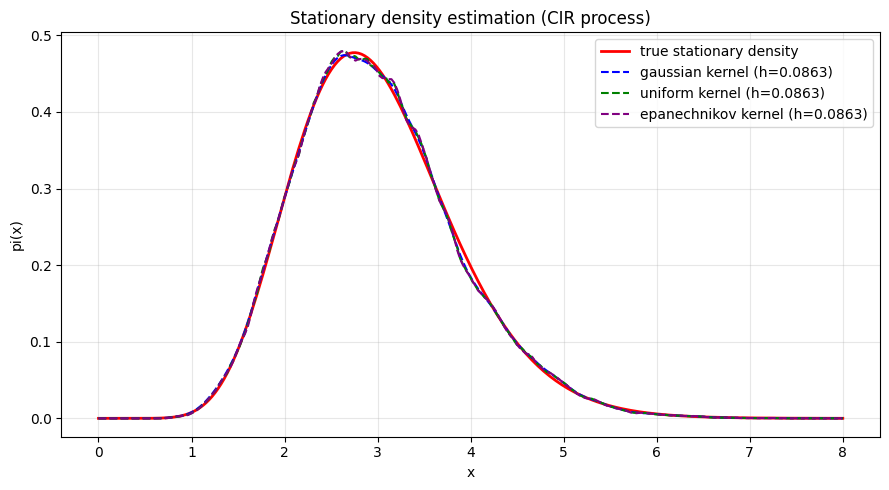

In [8]:
density_grid = np.linspace(0, 8, 250)

_, scott_bandwidth = StationaryDistributionKernelEstimator(
    density_grid,
    stationary_sample,
    kernel_name="gaussian"
)

true_stationary_density = cir_process.StationaryDistribution(density_grid)

gaussian_estimate, _ = StationaryDistributionKernelEstimator(
    density_grid,
    stationary_sample,
    kernel_name="gaussian",
    bandwidth=scott_bandwidth
)

uniform_estimate, _ = StationaryDistributionKernelEstimator(
    density_grid,
    stationary_sample,
    kernel_name="uniform",
    bandwidth=scott_bandwidth
)

epanechnikov_estimate, _ = StationaryDistributionKernelEstimator(
    density_grid,
    stationary_sample,
    kernel_name="epanechnikov",
    bandwidth=scott_bandwidth
)

plt.figure(figsize=(9, 5))
plt.plot(density_grid, true_stationary_density, color="red", linewidth=2, label="true stationary density")
plt.plot(density_grid, gaussian_estimate, linestyle="--", color="blue",
         label=f"gaussian kernel (h={scott_bandwidth:.4f})")
plt.plot(density_grid, uniform_estimate, linestyle="--", color="green",
         label=f"uniform kernel (h={scott_bandwidth:.4f})")
plt.plot(density_grid, epanechnikov_estimate, linestyle="--", color="purple",
         label=f"epanechnikov kernel (h={scott_bandwidth:.4f})")

plt.xlabel("x")
plt.ylabel("pi(x)")
plt.title("Stationary density estimation (CIR process)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Выводы

- Ядерная оцнека для процесса Кокса построена корректно - все три оценки хорошо согласуются с теоретической плотностью. Правило скотта дало разумную ширину окна для совпадения плотностей

- При использовании большой выборки стац. режима различия между ядрами - небольшие

***


Задача 2. Исследование правила Скотта для ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



In [9]:
np.random.seed(42)

cir_params = [6.0, 2.0, 1.0]
density_grid = np.linspace(0, 8, 150) # for comparison

# reference stationary density
reference_cir = CIRprocess(cir_params, T=1, Nx=1, Nt=1)
true_stationary_density = reference_cir.StationaryDistribution(density_grid)

def mean_squared_error(estimated_density, true_density):
    return np.mean((estimated_density - true_density) ** 2)

Построение 3D поверхности зависимости ошибки от шага дискретизации и ширины окна: 

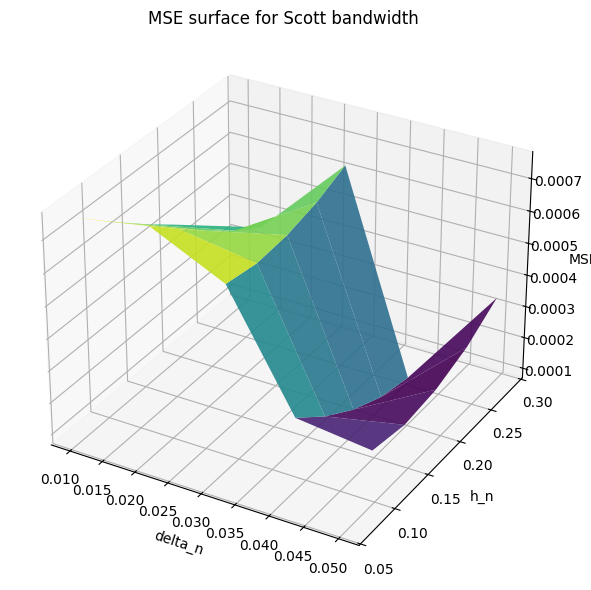

In [10]:
# surface settings
simulation_horizon = 100
time_step_values = [0.01, 0.02, 0.03, 0.04, 0.05]
bandwidth_multipliers = [0.5, 0.75, 1.0, 1.25, 1.5]

mse_surface = np.zeros((len(time_step_values), len(bandwidth_multipliers)))
bandwidth_surface = np.zeros((len(time_step_values), len(bandwidth_multipliers)))

for dt_index, current_dt in enumerate(time_step_values):
    current_steps = int(simulation_horizon / current_dt)

    cir_process = CIRprocess(cir_params, simulation_horizon, 1, current_steps)
    cir_process.init_state = cir_process.StationaryState()

    _, path_data = cir_process.ExactSolution()
    stationary_sample = path_data.flatten()

    sample_size = stationary_sample.size
    scott_bandwidth = np.std(stationary_sample, ddof=1) * sample_size ** (-1 / 5)

    for bandwidth_index, multiplier in enumerate(bandwidth_multipliers):
        current_bandwidth = multiplier * scott_bandwidth

        estimated_density, _ = StationaryDistributionKernelEstimator(
            density_grid,
            stationary_sample,
            kernel_name="gaussian",
            bandwidth=current_bandwidth
        )

        mse_surface[dt_index, bandwidth_index] = mean_squared_error(
            estimated_density,
            true_stationary_density
        )
        bandwidth_surface[dt_index, bandwidth_index] = current_bandwidth

delta_grid, bandwidth_grid = np.meshgrid(time_step_values, bandwidth_multipliers, indexing="ij")

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(delta_grid, bandwidth_surface, mse_surface, cmap="viridis", alpha=0.9)

ax.set_xlabel("delta_n")
ax.set_ylabel("h_n")
ax.set_zlabel("MSE")
ax.set_title("MSE surface for Scott bandwidth")
plt.tight_layout()
plt.show()

Проверка сходимости оценки к истинной плотности при росте кол-ва наблюдений n (фиксируем шаг, увеличивает горизонт наблюдения, пересчитываем ширину окна по правилу Скотта):

In [11]:
# convergence experiment settings
fixed_dt = 0.01
horizon_values = [20, 50, 100, 200, 500]

convergence_rows = []

for current_horizon in horizon_values:
    current_steps = int(current_horizon / fixed_dt)

    cir_process = CIRprocess(cir_params, current_horizon, 1, current_steps)
    cir_process.init_state = cir_process.StationaryState()

    _, path_data = cir_process.ExactSolution()
    stationary_sample = path_data.flatten()

    sample_size = stationary_sample.size
    scott_bandwidth = np.std(stationary_sample, ddof=1) * sample_size ** (-1 / 5)

    estimated_density, _ = StationaryDistributionKernelEstimator(
        density_grid,
        stationary_sample,
        kernel_name="gaussian",
        bandwidth=scott_bandwidth
    )

    current_mse = mean_squared_error(estimated_density, true_stationary_density)

    convergence_rows.append({
        "T": current_horizon,
        "n": sample_size,
        "Scott bandwidth": scott_bandwidth,
        "MSE": current_mse
    })

convergence_table = pd.DataFrame(convergence_rows)
convergence_table

,T,n,Scott bandwidth,MSE
0,20,2001,0.187556,0.002641
1,50,5001,0.169902,0.000561
2,100,10001,0.130797,0.000214
3,200,20001,0.124610,0.000131
4,500,50001,0.100841,0.000071


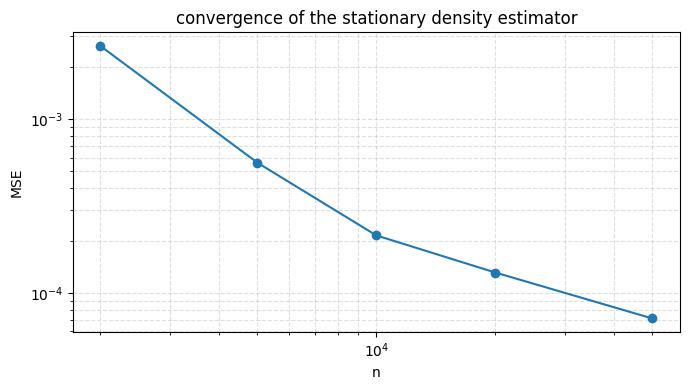

In [12]:
plt.figure(figsize=(7, 4))
plt.loglog(convergence_table["n"], convergence_table["MSE"], marker="o")
plt.xlabel("n")
plt.ylabel("MSE")
plt.title("convergence of the stationary density estimator")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Выводы

- По 3D графику видно, что ошибка аппроксимации зависит и от шага дискретизации, и от ширины окна, причем лучший результат достигается при промежуточных значениях ширины окна

- Увеличение числа наблюдений дает уменьше ширины окна по правилу Скотта и MSE устойчиво снижает, что подтверждает сходимость оценки к истинной плотности

***

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Проведите исследование влияния размера окна $h$ на оценки.

5. Сделайте выводы.


***

Зададим параметры процесса и сгенерируем ону длинную траекторию в стационарном режиме. А также подготовим сетку для восстановления коэффициентов:

In [17]:
np.random.seed(42)

cir_params = [6.0, 2.0, 1.0]

# long stationary trajectory
T = 1000
Nt = 200000
Nx = 1

cir_process = CIRprocess(cir_params, T, Nx, Nt)
cir_process.init_state = cir_process.StationaryState()

time_grid, path_data = cir_process.ExactSolution()

sample_path = path_data.flatten()
dt = T / Nt

# grid for nonparametric recovery
x_grid = np.linspace(0.2, 8.0, 200)

# true model coeffs
true_drift = cir_process.bxt(x_grid, 0, cir_params)
true_diffusion = cir_process.sigmaxt(x_grid, 0, cir_params)

Методы ядра и непараметрических оценок Флоренс-Змиру для оценки влияния окна:

In [19]:
def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def DriftKernelEstimator(grid_points, sample_values, dt, bandwidth):
    increments = sample_values[1:] - sample_values[:-1]
    kernel_matrix = gaussian_kernel((grid_points[:, None] - sample_values[:-1][None, :]) / bandwidth)

    numerator = kernel_matrix @ increments
    denominator = np.sum(kernel_matrix, axis=1) * dt

    return numerator / np.maximum(denominator, 1e-12)

def DiffusionKernelEstimator(grid_points, sample_values, dt, bandwidth):
    increments = sample_values[1:] - sample_values[:-1]
    kernel_matrix = gaussian_kernel((grid_points[:, None] - sample_values[:-1][None, :]) / bandwidth)

    numerator = kernel_matrix @ (increments**2)
    denominator = np.sum(kernel_matrix, axis=1) * dt

    return numerator / np.maximum(denominator, 1e-12)

# scott bandwidth
sample_size = len(sample_path)
scott_bandwidth = np.std(sample_path, ddof=1) * sample_size ** (-1 / 5)
bandwidth_multipliers = [0.5, 1.0, 1.5]
bandwidth_values = [multiplier * scott_bandwidth for multiplier in bandwidth_multipliers]

Графики восстановленных параметров для разных значений окна:

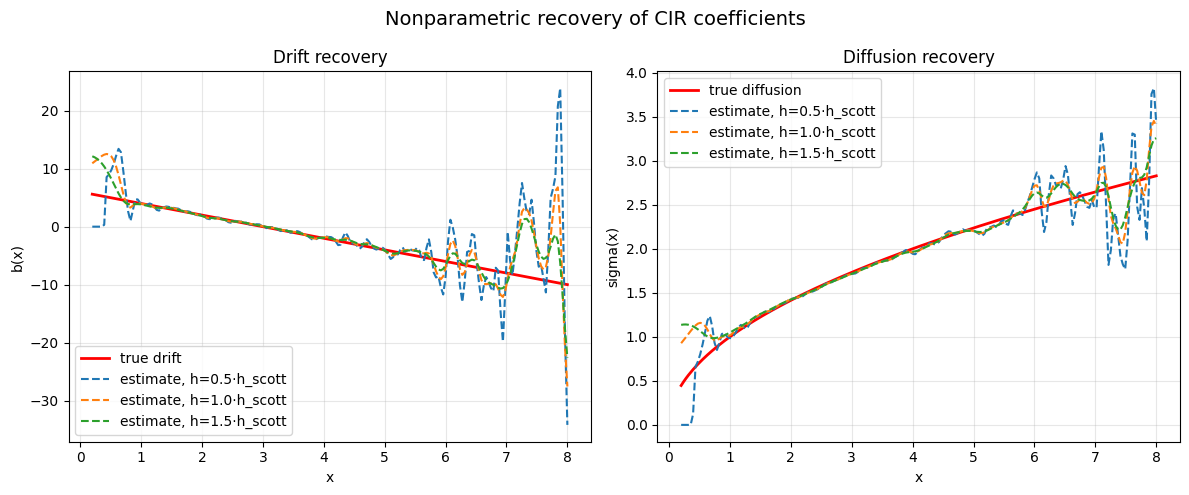

In [20]:
plt.figure(figsize=(12, 5))

# drift recovery
plt.subplot(1, 2, 1)
plt.plot(x_grid, true_drift, color="red", linewidth=2, label="true drift")

for current_bandwidth, multiplier in zip(bandwidth_values, bandwidth_multipliers):
    drift_estimate = DriftKernelEstimator(x_grid, sample_path, dt, current_bandwidth)
    plt.plot(
        x_grid,
        drift_estimate,
        linestyle="--",
        label=f"estimate, h={multiplier:.1f}·h_scott"
    )

plt.title("Drift recovery")
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(alpha=0.3)
plt.legend()

# diffusion recovery
plt.subplot(1, 2, 2)
plt.plot(x_grid, true_diffusion, color="red", linewidth=2, label="true diffusion")

for current_bandwidth, multiplier in zip(bandwidth_values, bandwidth_multipliers):
    diffusion_sq_estimate = DiffusionKernelEstimator(x_grid, sample_path, dt, current_bandwidth)
    diffusion_estimate = np.sqrt(np.maximum(diffusion_sq_estimate, 0))
    plt.plot(
        x_grid,
        diffusion_estimate,
        linestyle="--",
        label=f"estimate, h={multiplier:.1f}·h_scott"
    )

plt.title("Diffusion recovery")
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(alpha=0.3)
plt.legend()

plt.suptitle("Nonparametric recovery of CIR coefficients", fontsize=14)
plt.tight_layout()
plt.show()

Оценка шумности на краях области и в центре:

In [21]:
# estimates with Scott bandwidth
drift_estimate_scott = DriftKernelEstimator(x_grid, sample_path, dt, scott_bandwidth)
diffusion_sq_estimate_scott = DiffusionKernelEstimator(x_grid, sample_path, dt, scott_bandwidth)
diffusion_estimate_scott = np.sqrt(np.maximum(diffusion_sq_estimate_scott, 0))

# edge masks
left_edge_mask = x_grid < 1.5
center_mask = (x_grid >= 1.5) & (x_grid <= 4.5)
right_edge_mask = x_grid > 4.5

drift_error = drift_estimate_scott - true_drift
diffusion_error = diffusion_estimate_scott - true_diffusion

noise_summary = pd.DataFrame({
    "region": ["left edge", "center", "right edge"],
    "drift error std": [
        np.std(drift_error[left_edge_mask]),
        np.std(drift_error[center_mask]),
        np.std(drift_error[right_edge_mask]),
    ],
    "diffusion error std": [
        np.std(diffusion_error[left_edge_mask]),
        np.std(diffusion_error[center_mask]),
        np.std(diffusion_error[right_edge_mask]),
    ]
})

print(f"Scott bandwidth: {scott_bandwidth:.6f}")
noise_summary

Scott bandwidth: 0.076115


,region,drift error std,diffusion error std
0,left edge,3.134117,0.193309
1,center,0.208315,0.015680
2,right edge,4.918090,0.217608


#### Выводы

- Оценки Флоренс-Змиру корректно восстанавливавют коэф-ы дрифта и диффузии (особенно в центральной области), на краях области оценки более шумные, что можно объяснить недостаточностью данных для локального усреднения

- Размер окна h существенно влияет на качество восстановления - при малых значениях оценки шумнее, при больших значениях они более гладкие, но местами сильнее сглаживают детали

- Правило Скотта дало разумную ширину окна - оптимум между шумностью и сглаживанием для непараметрического восстановления параметров СДУ

***


Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.

3. Приведите необходимые иллюстративные графики: на усредненные кривые траекторий наложите бары стандарных отклонений.

4. Сделайте выводы.



***

Задание параметров и генерация 10 ансамблей для разных начальных точек:

In [ ]:
np.random.seed(42)

cir_params = [6.0, 2.0, 1.0]

T = 200
Nt = 20000
Nx = 1

initial_states = np.linspace(0.5, 9.0, 10)
n_replications = 20 # num of trajectories in each ensemble

time_grid = np.linspace(0, T, Nt + 1)

# 1 trajectory for each initial state (ergodicity illustration)
single_trajectories = []

for initial_value in initial_states:
    cir_process = CIRprocess(cir_params, T, Nx, Nt, init_state=np.array([initial_value]))
    _, trajectory_data = cir_process.ExactSolution()
    single_trajectories.append(trajectory_data[:, 0])

single_trajectories = np.array(single_trajectories)

ensemble_trajectories = {}

for initial_value in initial_states:
    trajectory_matrix = np.zeros((n_replications, Nt + 1))

    for replication_index in range(n_replications):
        cir_process = CIRprocess(cir_params, T, Nx, Nt, init_state=np.array([initial_value]))
        _, trajectory_data = cir_process.ExactSolution()
        trajectory_matrix[replication_index] = trajectory_data[:, 0]

    ensemble_trajectories[initial_value] = trajectory_matrix

График 10 траекторий, стартующих из разных начальных точек (визуальная демонстрация эргодичности):

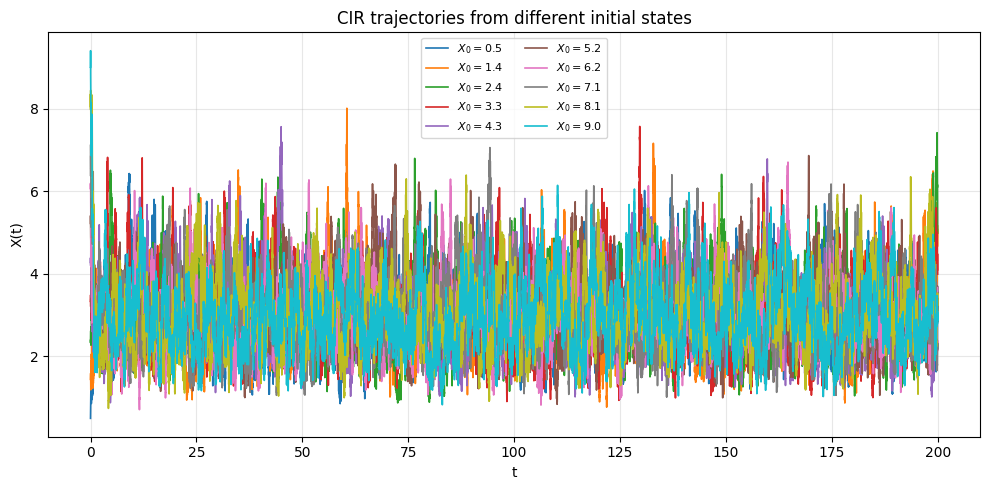

In [24]:
plt.figure(figsize=(10, 5))

for initial_value, trajectory_values in zip(initial_states, single_trajectories):
    plt.plot(time_grid, trajectory_values, linewidth=1.2, label=f"$X_0={initial_value:.1f}$")

plt.title("CIR trajectories from different initial states")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

Усредненные графики + стандартные отклонения на разреженной временной сетке:

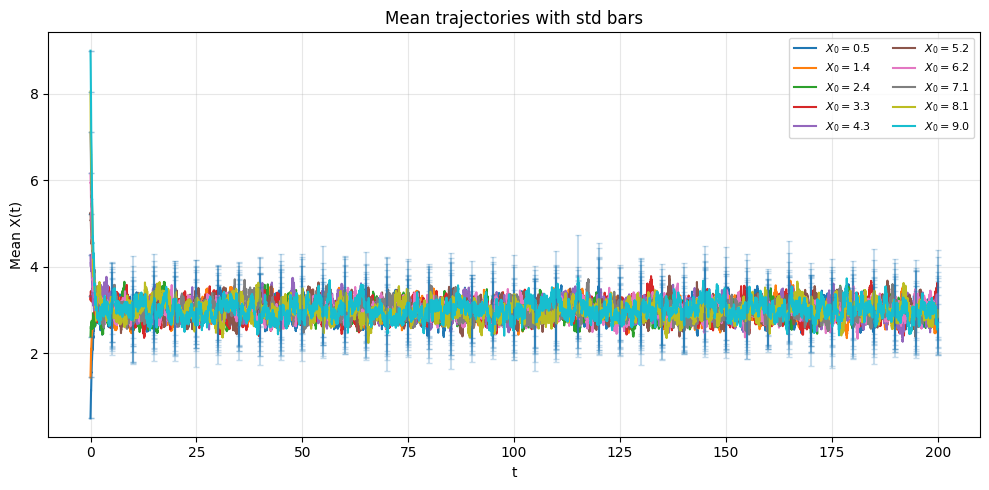

In [27]:
plt.figure(figsize=(10, 5))

error_step = Nt // 40
error_indices = np.arange(0, Nt + 1, error_step)

for initial_value in initial_states:
    trajectory_matrix = ensemble_trajectories[initial_value]

    mean_trajectory = trajectory_matrix.mean(axis=0)
    std_trajectory = trajectory_matrix.std(axis=0, ddof=1)

    plt.plot(time_grid, mean_trajectory, linewidth=1.5, label=f"$X_0={initial_value:.1f}$")
    plt.errorbar(
        time_grid[error_indices],
        mean_trajectory[error_indices],
        yerr=std_trajectory[error_indices],
        fmt="none",
        alpha=0.25,
        capsize=2
    )

plt.title("Mean trajectories with std bars")
plt.xlabel("t")
plt.ylabel("Mean X(t)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

Исследование поздней части траекторий для сравнения со стационарной плотностью:

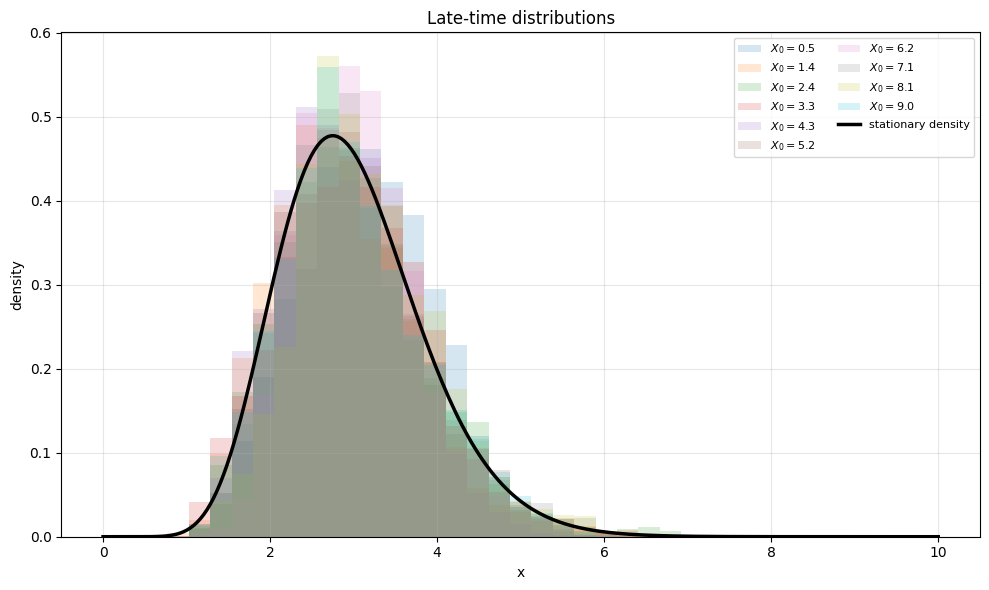

In [29]:
# tail of each trajectory
tail_start_index = int(0.7 * (Nt + 1))
density_grid = np.linspace(0, 10, 250)
histogram_bins = np.linspace(0, 10, 40)

reference_process = CIRprocess(cir_params, 1, 1, 1)
true_stationary_density = reference_process.StationaryDistribution(density_grid)

plt.figure(figsize=(10, 6))

for initial_value, trajectory_values in zip(initial_states, single_trajectories):
    late_sample = trajectory_values[tail_start_index:]

    plt.hist(
        late_sample,
        bins=histogram_bins,
        density=True,
        alpha=0.18,
        label=f"$X_0={initial_value:.1f}$"
    )

plt.plot(density_grid, true_stationary_density, color="black", linewidth=2.5, label="stationary density")

plt.title("Late-time distributions")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

#### Выводы

- Доказана эргодичность CIR-процесса - несмотря на разные начальные значения, траектории со временем переходят в одну и ту же область колебаний. Средние траектории также быстро сблизились, а станд.отклонения стали сопоставивыми

- Гистограммы поздних участков траекторий тоже имеют практически одинаковую форму и хорошо согласуются с теоретической стационарной плотностью, что подтверждает условие перемеширование (mixing)

***

Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения (модель и ее параметры использовать из задачи 3).

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Приведите иллюстративные графики (теоретические PDF, CDF и их оценки, теоретические значения квартилей и их оценки).

4. Сделайте выводы.


***

Генерация длинной траектории и формирование разреженной выборки из поздней части для стат.проверки:

In [39]:
np.random.seed(42)

cir_params = [6.0, 2.0, 1.0] # from task 3

T = 2000
Nt = 500000
Nx = 1

cir_process = CIRprocess(cir_params, T, Nx, Nt)
cir_process.init_state = cir_process.StationaryState()

time_grid, path_data = cir_process.ExactSolution()
full_sample = path_data.flatten()

# late part of the path
tail_start_index = int(0.7 * len(full_sample))
thinning_step = 200 # thinning it to reduce dependence
verification_sample = full_sample[tail_start_index::thinning_step]

print(f"trajectory size: {len(full_sample)}")
print(f"verification sample size: {len(verification_sample)}")

trajectory size: 500001
verification sample size: 751


Проверка критерием Колмогорова-Смирнова и 90% квантиль стац.распределения:

In [40]:
from scipy.stats import kstest, ncx2

# stationary dist. params
theta1, theta2, theta3 = cir_params
kappa = theta2
theta = theta1 / theta2
sigma = theta3

c_param = 2 * kappa / sigma**2
q_param = 2 * kappa * theta / sigma**2 - 1

def theoretical_stationary_cdf(x):
    return ncx2.cdf(2 * c_param * x, 2 * q_param + 2, 0)

ks_statistic, ks_pvalue = kstest(verification_sample, theoretical_stationary_cdf)

theoretical_quantile_90 = ncx2.ppf(0.9, 2 * q_param + 2, 0) / (2 * c_param)

print(f"KS statistic: {ks_statistic:.6f}")
print(f"KS p-value  : {ks_pvalue:.6f}")
print(f"theory 90% quantile: {theoretical_quantile_90:.6f}")

KS statistic: 0.033732
KS p-value  : 0.352081
theory 90% quantile: 4.149531


Восстановление стационарной плотности с помощью гауссовской KDE по правилу Скотта + оценка pdf/cdf:

In [41]:
def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

density_grid = np.linspace(0, 8, 400)

sample_size = len(verification_sample)
scott_bandwidth = np.std(verification_sample, ddof=1) * sample_size ** (-1 / 5)

kernel_matrix = gaussian_kernel((density_grid[:, None] - verification_sample[None, :]) / scott_bandwidth)
estimated_density = np.sum(kernel_matrix, axis=1) / (sample_size * scott_bandwidth)

grid_step = density_grid[1] - density_grid[0]
estimated_cdf = np.cumsum(estimated_density) * grid_step
estimated_cdf /= estimated_cdf[-1]

estimated_quantile_90 = np.interp(0.9, estimated_cdf, density_grid)

theoretical_density = cir_process.StationaryDistribution(density_grid)
theoretical_cdf = theoretical_stationary_cdf(density_grid)

print(f"Scott bandwidth: {scott_bandwidth:.6f}")
print(f"estimated 90% quantile: {estimated_quantile_90:.6f}")
print(f"quantile abs error: {abs(estimated_quantile_90 - theoretical_quantile_90):.6f}")

Scott bandwidth: 0.230641
estimated 90% quantile: 4.153217
quantile abs error: 0.003686


Графики CDF и PDF + квантили:

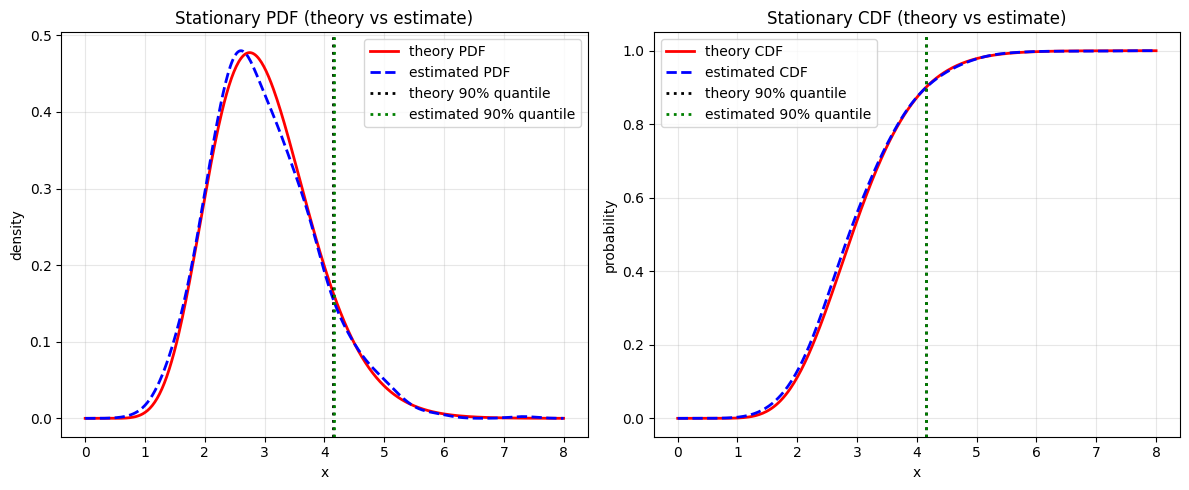

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PDF
axes[0].plot(density_grid, theoretical_density, color="red", linewidth=2, label="theory PDF")
axes[0].plot(density_grid, estimated_density, color="blue", linestyle="--", linewidth=2, label="estimated PDF")
axes[0].axvline(theoretical_quantile_90, color="black", linestyle=":", linewidth=2, label="theory 90% quantile")
axes[0].axvline(estimated_quantile_90, color="green", linestyle=":", linewidth=2, label="estimated 90% quantile")
axes[0].set_title("Stationary PDF (theory vs estimate)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("density")
axes[0].grid(alpha=0.3)
axes[0].legend()

# CDF
axes[1].plot(density_grid, theoretical_cdf, color="red", linewidth=2, label="theory CDF")
axes[1].plot(density_grid, estimated_cdf, color="blue", linestyle="--", linewidth=2, label="estimated CDF")
axes[1].axvline(theoretical_quantile_90, color="black", linestyle=":", linewidth=2, label="theory 90% quantile")
axes[1].axvline(estimated_quantile_90, color="green", linestyle=":", linewidth=2, label="estimated 90% quantile")
axes[1].set_title("Stationary CDF (theory vs estimate)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("probability")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Выводы

- Критерий Колмогорова-Смирнова не выявил статистически значимых различий между выборкой из симуляции и теор. стац. распределением (по p-value). А также восстановленная плотность хорошо совпадает с теорией согласно графикам

- Квантильное сравнение тоже успешное, абсолютная ошибка мала, то есть KDE позволяет восстанавливать квантильные характеристики распределения CIR